In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions 
from sklearn.ensemble import RandomForestClassifier


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Features (Fixed)
1) Relative Pricing	
- (price / average pricing) of listings with same conditions (same neighborhood, # of bedrooms and bathrooms, and roomtype)
2) Housing Characteristics:
- Room Type 
- num of Bedrooms
- num of Bathrooms
- num of Beds
- num of Accommodates
- Is_Long_term: 1 if minimum_nights > 7, 0 if minimum_nights <= 7
3) Host Characteristics:
- Host_Response TIme
- Host_Identity_Verified
4) Other Users Experience/Engagement:
- number_of_reviews (TBD vvn: check the colinearity btw scoring and num of review)
- recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
- estimated_occupancy_l365d


In [2]:
sea = pd.read_csv("seattle_filtered.csv")

In [3]:
# create relative price columns
# Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
sea["avg_price_group"] = sea.groupby(group_cols)["price"].transform("mean")
sea["relative_price"] = sea["price"] / sea["avg_price_group"]

In [4]:
# host response time
mapping_host_response_time = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

sea['host_response_time'] = sea['host_response_time'].map(mapping_host_response_time)

In [5]:
# is_long_term
## minimum nights -> short-term listing vs. long-term listing
sea['is_long_term'] = (sea["minimum_nights"] > 7).astype(int)

In [6]:
# recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
sea['recent_Review_proportion'] = sea['number_of_reviews_ltm'] / sea['number_of_reviews']

In [7]:
features = [
    "review_scores_rating",
    # relative pricing
    "relative_price",
    # housing characteristics
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "room_type",
    "is_long_term",
    # host characteristics
    "host_response_time",
    "host_identity_verified", 
    # others
    "number_of_reviews",
    "recent_Review_proportion",
    "estimated_occupancy_l365d"
]

### Neighborhood Analysis (RF)

In [8]:
sea['neighbourhood_group_cleansed'].unique()

array(['Other neighborhoods', 'Ballard', 'Cascade', 'Rainier Valley',
       'Magnolia', 'West Seattle', 'Queen Anne', 'Downtown',
       'Capitol Hill', 'Beacon Hill', 'Lake City', 'Central Area',
       'University District', 'Delridge', 'Northgate', 'Seward Park',
       'Interbay'], dtype=object)

In [9]:
def run_rf_by_area(df, area_name, target_col="review_scores_rating", min_rows=30,
                   test_size=0.2, random_state=42, plot_top_n=10):
    df = df.dropna(subset=[target_col]).copy()

    if len(df) < min_rows:
        raise ValueError(f"{area_name}: Not enough rows ({len(df)})")

    # threshold
    thres = df[target_col].quantile(0.5)

    # X, y
    X = df.drop(columns=[target_col]).copy()
    y = (df[target_col] >= thres).astype(int)

    # one-hot encoding
    X = pd.get_dummies(X, drop_first=True)

    if y.nunique() < 2:
        raise ValueError(f"{area_name}: Only one class in target")

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # model
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=random_state
    )
    rf.fit(X_train, y_train)

    # prediction
    y_pred = rf.predict(X_test)

    # feature importance
    importance = pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    top_features = importance.head(plot_top_n)

    # results
    result = {
        "area": area_name,
        "threshold": thres,
        "accuracy": accuracy_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "feature_importance": importance,
        "top_features": top_features,
        "model": rf
    }

    return result

In [10]:
# area list
area_dfs = [
    "Downtown",
    "Central Area",
    "Queen Anne",
    "Beacon Hill",
    "Capitol Hill",
    "West Seattle",
    "Ballard",
    "Rainier Valley",
    "Cascade",
    "Northgate",
    "University District"]

all_results = {}

for i in range(len(area_dfs)):
    try:
        tmp = sea[sea['neighbourhood_group_cleansed'] == area_dfs[i]]
        tmp = tmp[features]
        result = run_rf_by_area(tmp, area_dfs[i])
        all_results[area_dfs[i]] = result
        print(f"\n=== {area_dfs[i]} ===")
        print("Threshold:", result["threshold"])
        print("Accuracy:", result["accuracy"])
        print("Confusion Matrix:\n", result["confusion_matrix"])
    except Exception as e:
        print(f"\n=== {area_dfs[i]} ===")
        print("Error:", e)


=== Downtown ===
Threshold: 4.81
Accuracy: 0.7972972972972973
Confusion Matrix:
 [[50 23]
 [ 7 68]]

=== Central Area ===
Threshold: 4.88
Accuracy: 0.6982758620689655
Confusion Matrix:
 [[35 21]
 [14 46]]

=== Queen Anne ===
Threshold: 4.89
Accuracy: 0.6767676767676768
Confusion Matrix:
 [[30 19]
 [13 37]]

=== Beacon Hill ===
Threshold: 4.88
Accuracy: 0.6
Confusion Matrix:
 [[12 12]
 [ 8 18]]

=== Capitol Hill ===
Threshold: 4.85
Accuracy: 0.7818181818181819
Confusion Matrix:
 [[45  9]
 [15 41]]

=== West Seattle ===
Threshold: 4.94
Accuracy: 0.632183908045977
Confusion Matrix:
 [[22 18]
 [14 33]]

=== Ballard ===
Threshold: 4.94
Accuracy: 0.6164383561643836
Confusion Matrix:
 [[22 13]
 [15 23]]

=== Rainier Valley ===
Threshold: 4.88
Accuracy: 0.696969696969697
Confusion Matrix:
 [[20 13]
 [ 7 26]]

=== Cascade ===
Threshold: 4.0
Accuracy: 0.9387755102040817
Confusion Matrix:
 [[20  3]
 [ 0 26]]

=== Northgate ===
Threshold: 4.83
Accuracy: 0.6097560975609756
Confusion Matrix:
 [[10 

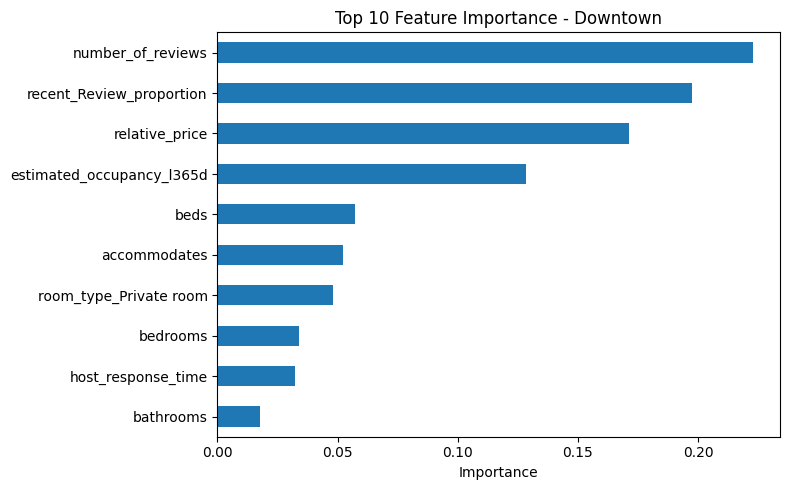

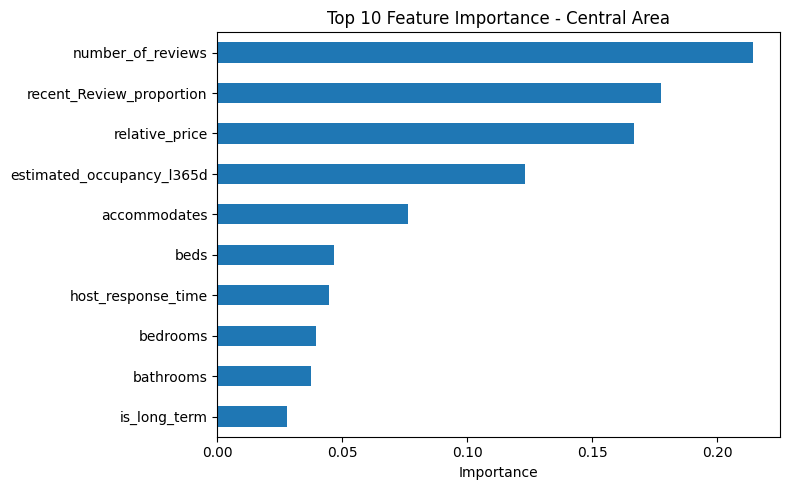

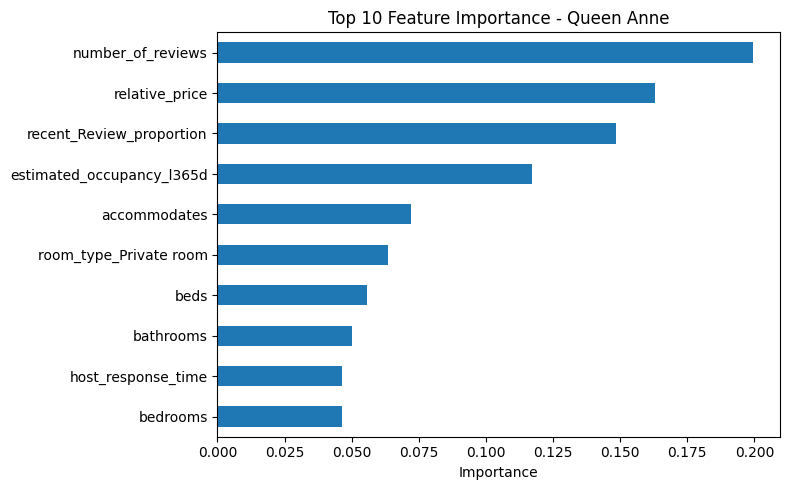

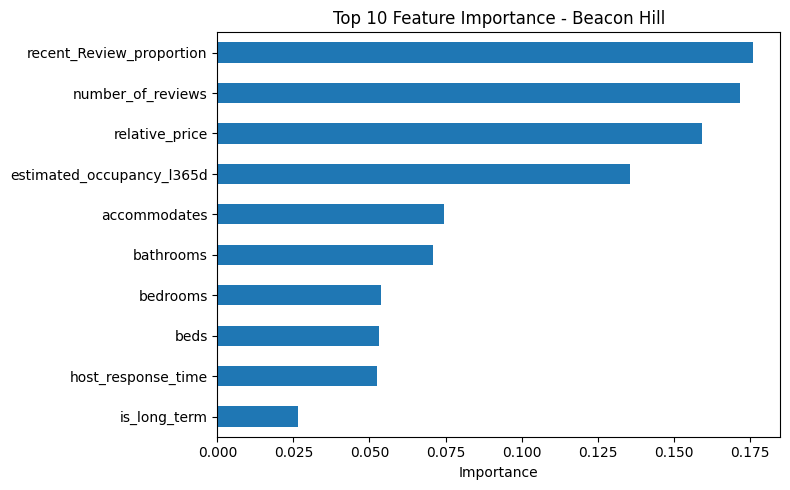

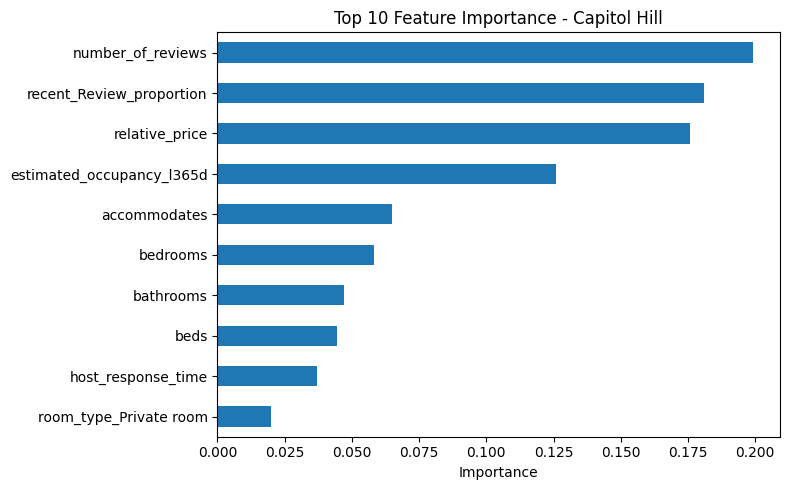

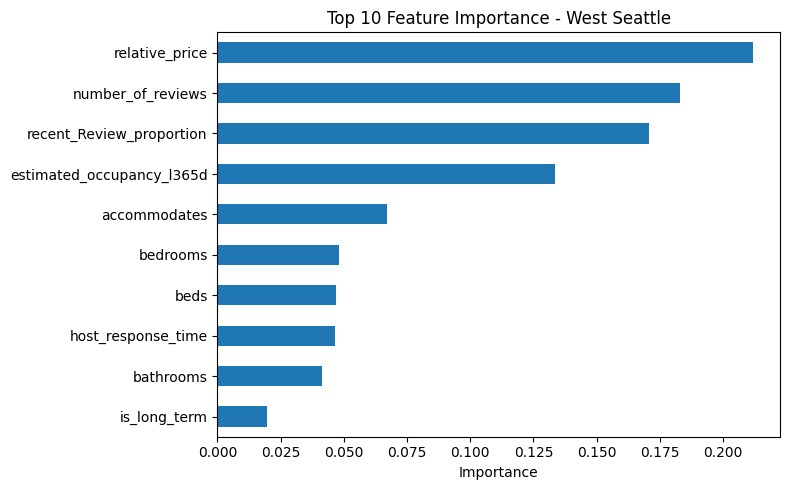

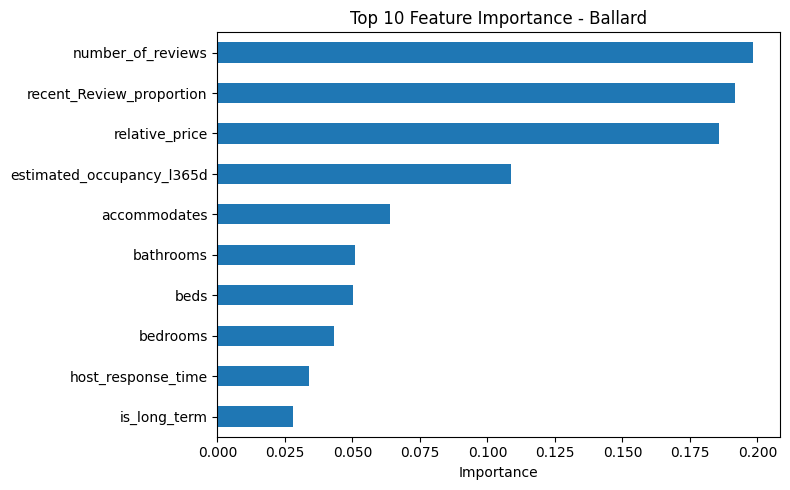

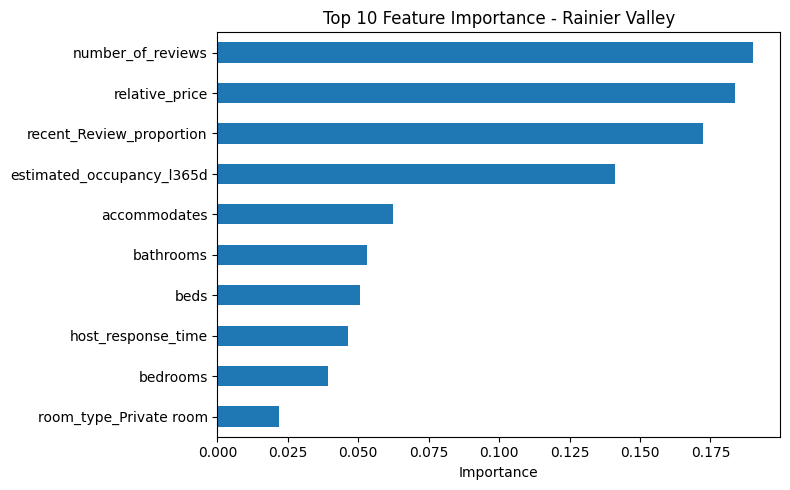

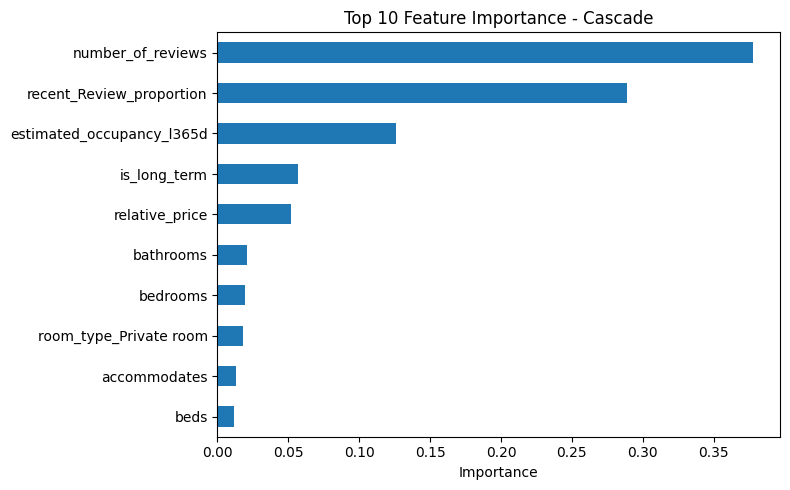

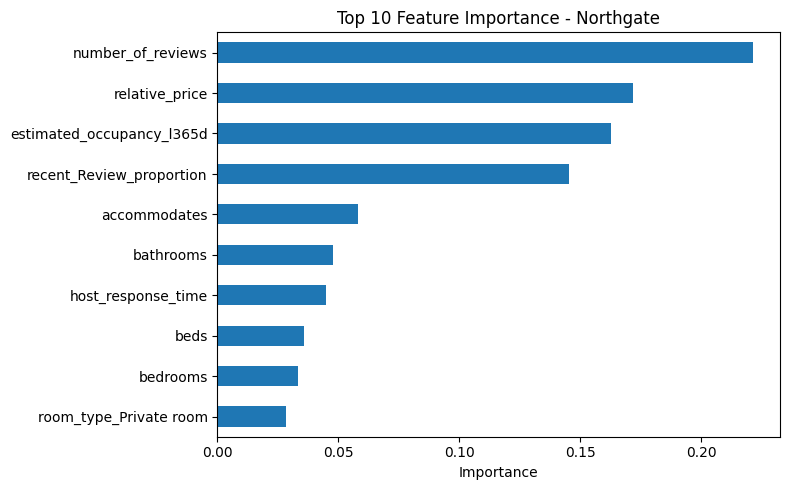

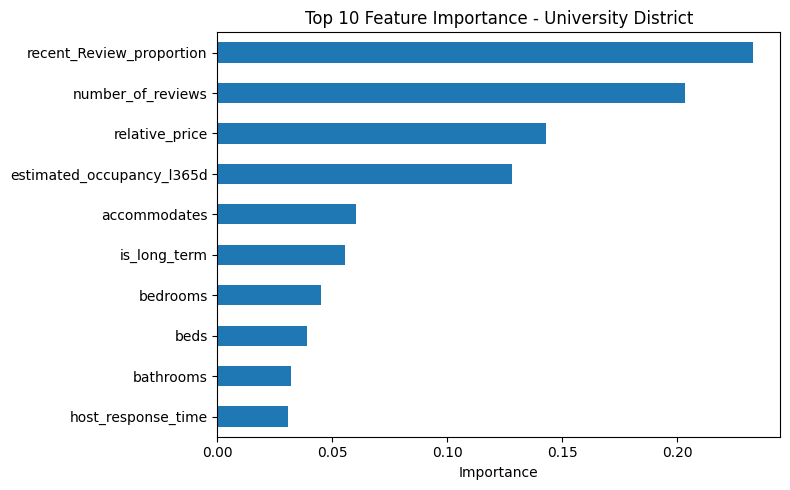

In [11]:
for area_name, result in all_results.items():
    plt.figure(figsize=(8, 5))
    result["top_features"].sort_values(ascending=True).plot(kind="barh")
    plt.title(f"Top 10 Feature Importance - {area_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()